In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import roc_auc_score, roc_curve, classification_report, confusion_matrix, r2_score, mean_squared_error

In [ ]:
import kagglehub
import pandas as pd
import os

# Download the dataset from Kaggle (returns the local folder path)
path = kagglehub.dataset_download("notnihao/patient-records")

print("Path to dataset files:", path)
print("Files:", os.listdir(path))

# Load the CSV file into a Pandas DataFrame (our working table of data)
df = pd.read_csv(os.path.join(path, "patient-records.csv"))
df.head()  # preview the first 5 rows

Using Colab cache for faster access to the 'patient-records' dataset.
Path to dataset files: /kaggle/input/patient-records
Files: ['patient-records.csv']


,ID,Age,Gender,BMI,Smoker,Region,Cost ($)
0,1,19,female,27.900,yes,southwest,16884.92400
1,2,18,male,33.770,no,southeast,1725.55230
2,3,28,male,33.000,no,southeast,4449.46200
3,4,33,male,22.705,no,northwest,21984.47061
4,5,32,male,28.880,no,northwest,3866.85520


Dataset Shape: (1338, 7)

First 5 Rows:
   ID  Age  Gender     BMI Smoker     Region     Cost ($)
0   1   19  female  27.900    yes  southwest  16884.92400
1   2   18    male  33.770     no  southeast   1725.55230
2   3   28    male  33.000     no  southeast   4449.46200
3   4   33    male  22.705     no  northwest  21984.47061
4   5   32    male  28.880     no  northwest   3866.85520

Readmitted Column Counts:
Cost ($)
1639.56310     2
2221.56445     1
19798.05455    1
13063.88300    1
13555.00490    1
              ..
1149.39590     1
37079.37200    1
4738.26820     1
2897.32350     1
4762.32900     1
Name: count, Length: 1337, dtype: int64


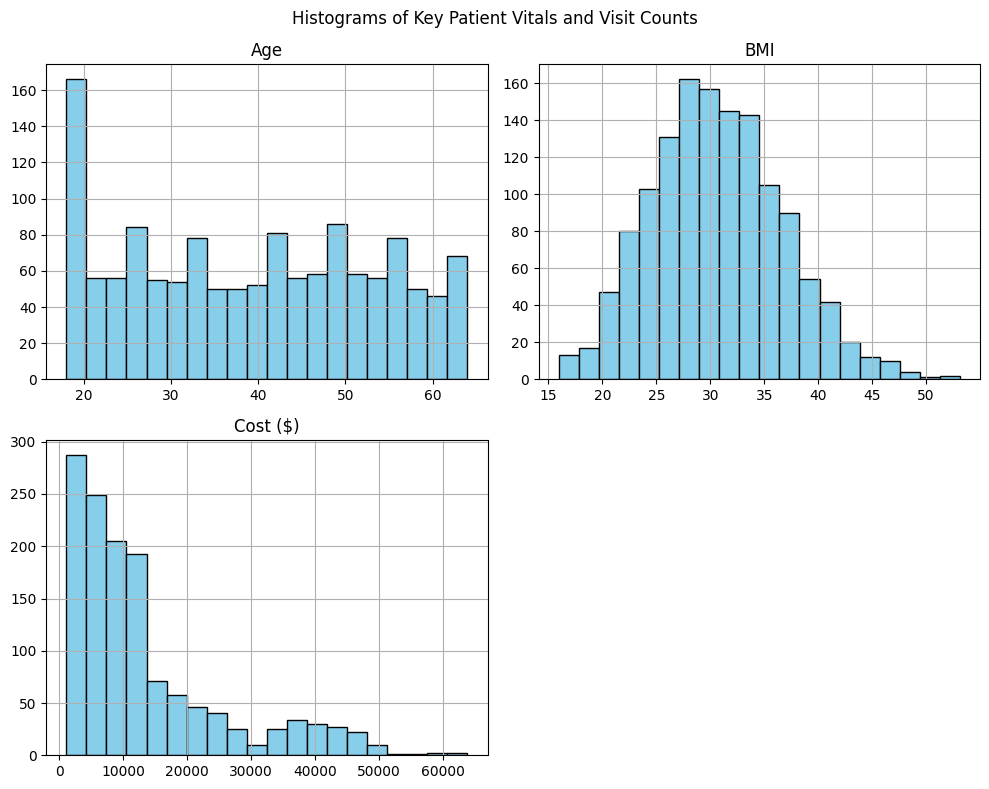

In [ ]:
print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
print(df.head())

# Check target variable distribution
print("\nReadmitted Column Counts:")
print(df['Cost ($)'].value_counts())

# Visualizing distributions of numeric clinical features
numeric_cols = ['Age', 'BMI', 'Cost ($)']

df[numeric_cols].hist(bins=20, figsize=(10, 8), color='skyblue', edgecolor='black')
plt.suptitle("Histograms of Key Patient Vitals and Visit Counts")
plt.tight_layout()
plt.show()

In [ ]:
# Impute numeric columns with median
num_cols = df.select_dtypes(include='number').columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Impute categorical columns with mode
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values handled.")

Missing values handled.


In [ ]:
# Convert categorical columns ('yes'/'no', strings) to numbers before splitting
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)
df.head()

,ID,Age,BMI,Cost ($),Gender_male,Smoker_yes,Region_northwest,Region_southeast,Region_southwest
0,1,19,27.900,16884.92400,False,True,False,False,True
1,2,18,33.770,1725.55230,True,False,False,True,False
2,3,28,33.000,4449.46200,True,False,False,True,False
3,4,33,22.705,21984.47061,True,False,True,False,False
4,5,32,28.880,3866.85520,True,False,True,False,False


In [ ]:
# Replace 'target_column_name' with your actual target (e.g., 'charges' or 'readmitted')
target_var = 'Cost ($)'

X = df.drop(columns=[target_var])
y = df[target_var]

### Performing Logistic Regression

To perform Logistic Regression, we need a binary target variable. I'll create a new target variable `High_Cost` where `True` indicates a cost above the median `Cost ($)` and `False` otherwise.

In [ ]:
# Calculate the median of 'Cost ($)'
median_cost = df['Cost ($)'].median()

# Create a new binary target variable 'High_Cost'
df['High_Cost'] = (df['Cost ($)'] > median_cost).astype(int)

# Display the value counts for the new target variable
print(df['High_Cost'].value_counts())
display(df.head())

High_Cost
1    669
0    669
Name: count, dtype: int64


,ID,Age,BMI,Cost ($),Gender_male,Smoker_yes,Region_northwest,Region_southeast,Region_southwest,High_Cost
0,1,19,27.900,16884.92400,False,True,False,False,True,1
1,2,18,33.770,1725.55230,True,False,False,True,False,0
2,3,28,33.000,4449.46200,True,False,False,True,False,0
3,4,33,22.705,21984.47061,True,False,True,False,False,1
4,5,32,28.880,3866.85520,True,False,True,False,False,0


Now, let's redefine our features `X_logistic` and target `y_logistic` for the Logistic Regression model, excluding the original `Cost ($)` column.

In [ ]:
X_logistic = df.drop(columns=['Cost ($)', 'High_Cost'])
y_logistic = df['High_Cost']

print("Features for Logistic Regression (X_logistic) shape:", X_logistic.shape)
print("Target for Logistic Regression (y_logistic) shape:", y_logistic.shape)

Features for Logistic Regression (X_logistic) shape: (1338, 8)
Target for Logistic Regression (y_logistic) shape: (1338,)


Next, we'll split the data into training and testing sets for the Logistic Regression model.

In [ ]:
X_train_logistic, X_test_logistic, y_train_logistic, y_test_logistic = train_test_split(
    X_logistic, y_logistic, test_size=0.2, random_state=42, stratify=y_logistic
)

print("Logistic Regression Training set shape:", X_train_logistic.shape)
print("Logistic Regression Testing set shape:", X_test_logistic.shape)

Logistic Regression Training set shape: (1070, 8)
Logistic Regression Testing set shape: (268, 8)


It's good practice to scale the numerical features before training a Logistic Regression model, especially when using regularization, to ensure that no single feature dominates the learning process due to its scale. We will use `StandardScaler`.

In [ ]:
scaler_logistic = StandardScaler()
X_train_logistic_scaled = scaler_logistic.fit_transform(X_train_logistic)
X_test_logistic_scaled = scaler_logistic.transform(X_test_logistic)

print("Features scaled for Logistic Regression.")

Features scaled for Logistic Regression.


Now we can train the `LogisticRegression` model on the scaled data. I will increase `max_iter` to ensure convergence.

In [ ]:
model_logistic = LogisticRegression(max_iter=1000, random_state=42)
model_logistic.fit(X_train_logistic_scaled, y_train_logistic)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


Finally, let's evaluate the performance of the Logistic Regression model using appropriate classification metrics.


Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.89      0.90       134
           1       0.89      0.92      0.90       134

    accuracy                           0.90       268
   macro avg       0.90      0.90      0.90       268
weighted avg       0.90      0.90      0.90       268


Confusion Matrix:
[[119  15]
 [ 11 123]]

ROC AUC Score: 0.9407440409890843


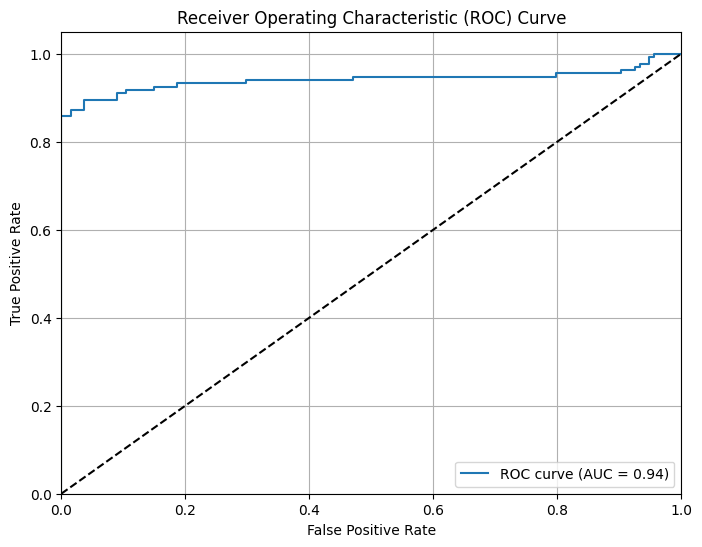

In [ ]:
y_pred_logistic = model_logistic.predict(X_test_logistic_scaled)
y_pred_proba_logistic = model_logistic.predict_proba(X_test_logistic_scaled)[:, 1]

print("\nClassification Report:")
print(classification_report(y_test_logistic, y_pred_logistic))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_logistic, y_pred_logistic))

print("\nROC AUC Score:", roc_auc_score(y_test_logistic, y_pred_proba_logistic))

# Plot ROC curve
fpr, tpr, _ = roc_curve(y_test_logistic, y_pred_proba_logistic)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc_score(y_test_logistic, y_pred_proba_logistic):.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (1070, 8)
Testing set shape: (268, 8)


In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [ ]:
y_pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))
print("Mean Squared Error (MSE):", mean_squared_error(y_test, y_pred))

R2 Score: 0.7785570381229305
Mean Squared Error (MSE): 34378738.9291962
